# Age Detection with Stage-Wise Regression CNN

This notebook implements a **2-stage regression model** inspired by SSR-Net for age estimation from face images.

**Core Idea:**
- **Stage 1** — Classify the face into a broad age group (coarse prediction)
- **Stage 2** — Using the Stage 1 output, regress the exact age (fine prediction)

The key difference from a plain regression model: Stage 2 is *conditioned* on Stage 1's group probabilities, so the two stages genuinely communicate.

**Dataset:** UTKFace (stratified subset ~7,000 images)
**Input:** 64×64 RGB face images
**Output:** Predicted age in years

## 1. Setup & Imports

In [1]:
!pip install kagglehub -q

In [2]:
import os, re, glob, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download Dataset

In [3]:
import kagglehub
dataset_path = kagglehub.dataset_download('jangedoo/utkface-new')
print('Dataset downloaded to:', dataset_path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Dataset downloaded to: /kaggle/input/utkface-new


## 3. Data Loading & Stratified Sampling

UTKFace filenames encode labels: `age_gender_race_timestamp.jpg`

We parse age from each filename, then do **stratified sampling** — equal images per age group — so the model does not become biased toward the most common ages in the dataset.

In [4]:
# ── Configuration ────────────────────────────────────────────────────────────
IMG_SIZE          = 64
BATCH_SIZE        = 32
SAMPLES_PER_GROUP = 1750   # x4 groups = 7000 total
VALIDATION_SPLIT  = 0.15
TEST_SPLIT        = 0.10
MAX_AGE           = 100.0  # Used to normalise age labels to [0, 1]

AGE_GROUPS = {
    0: '0-18  (Child/Teen)',
    1: '19-35 (Young Adult)',
    2: '36-60 (Middle-Aged)',
    3: '61+   (Senior)'
}
GROUP_LABELS = ['0-18', '19-35', '36-60', '61+']

def age_to_group(age):
    if age <= 18: return 0
    if age <= 35: return 1
    if age <= 60: return 2
    return 3

def parse_age(filepath):
    fname = os.path.basename(filepath)
    m = re.match(r'^(\d+)_', fname)
    if m:
        age = int(m.group(1))
        if 1 <= age <= 100:
            return age
    return None

# Collect all valid image paths
all_paths, all_ages, all_groups = [], [], []
for ext in ('*.jpg', '*.jpeg', '*.png'):
    for fpath in glob.glob(os.path.join(dataset_path, '**', ext), recursive=True):
        age = parse_age(fpath)
        if age is not None:
            all_paths.append(fpath)
            all_ages.append(age)
            all_groups.append(age_to_group(age))

print(f'Total valid images found: {len(all_paths)}')
for g, cnt in sorted(Counter(all_groups).items()):
    print(f'  Group {g} [{AGE_GROUPS[g]}]: {cnt} images')

Total valid images found: 66928
  Group 0 [0-18  (Child/Teen)]: 17202 images
  Group 1 [19-35 (Young Adult)]: 25576 images
  Group 2 [36-60 (Middle-Aged)]: 16774 images
  Group 3 [61+   (Senior)]: 7376 images


In [5]:
# ── Stratified Sampling ───────────────────────────────────────────────────────
sampled_paths, sampled_ages, sampled_groups = [], [], []

for group_id in range(4):
    indices = [i for i, g in enumerate(all_groups) if g == group_id]
    n = min(SAMPLES_PER_GROUP, len(indices))
    chosen = random.sample(indices, n)
    for i in chosen:
        sampled_paths.append(all_paths[i])
        sampled_ages.append(all_ages[i])
        sampled_groups.append(all_groups[i])

# Shuffle
combined = list(zip(sampled_paths, sampled_ages, sampled_groups))
random.shuffle(combined)
sampled_paths, sampled_ages, sampled_groups = zip(*combined)

sampled_paths  = list(sampled_paths)
sampled_ages   = np.array(sampled_ages,   dtype=np.float32)
sampled_groups = np.array(sampled_groups, dtype=np.int32)

print(f'Stratified sample size: {len(sampled_paths)}')
for g, cnt in sorted(Counter(sampled_groups.tolist()).items()):
    print(f'  Group {g} [{AGE_GROUPS[g]}]: {cnt} images')

Stratified sample size: 7000
  Group 0 [0-18  (Child/Teen)]: 1750 images
  Group 1 [19-35 (Young Adult)]: 1750 images
  Group 2 [36-60 (Middle-Aged)]: 1750 images
  Group 3 [61+   (Senior)]: 1750 images


In [6]:
# ── Train / Val / Test Split ──────────────────────────────────────────────────
paths_tv, paths_test, ages_tv, ages_test, groups_tv, groups_test = train_test_split(
    sampled_paths, sampled_ages, sampled_groups,
    test_size=TEST_SPLIT, random_state=SEED, stratify=sampled_groups
)

val_frac = VALIDATION_SPLIT / (1 - TEST_SPLIT)
paths_train, paths_val, ages_train, ages_val, groups_train, groups_val = train_test_split(
    paths_tv, ages_tv, groups_tv,
    test_size=val_frac, random_state=SEED, stratify=groups_tv
)

print(f'Train : {len(paths_train)} images')
print(f'Val   : {len(paths_val)} images')
print(f'Test  : {len(paths_test)} images')

Train : 5250 images
Val   : 1050 images
Test  : 700 images


## 4. Data Pipeline (tf.data)

The **training pipeline** includes light data augmentation (random horizontal flips, brightness and contrast jitter) to improve generalisation on our ~6,300 training images.

In [7]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img / 255.0

def augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    return tf.clip_by_value(img, 0.0, 1.0)

def make_train_sample(path, age, group):
    return augment(load_image(path)), {'group': group, 'age': age / MAX_AGE}

def make_eval_sample(path, age, group):
    return load_image(path), {'group': group, 'age': age / MAX_AGE}

def build_dataset(paths, ages, groups, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(ages), tf.constant(groups))
    )
    if training:
        ds = ds.shuffle(len(paths), seed=SEED)
        ds = ds.map(make_train_sample, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(make_eval_sample, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(paths_train, ages_train, groups_train, training=True)
val_ds   = build_dataset(paths_val,   ages_val,   groups_val)
test_ds  = build_dataset(paths_test,  ages_test,  groups_test)

# Sanity check
for imgs, labels in train_ds.take(1):
    print('Image batch shape :', imgs.shape)
    print('Age labels (years):', (labels["age"].numpy()[:5] * MAX_AGE).astype(int))
    print('Group labels      :', labels["group"].numpy()[:5])

Image batch shape : (32, 64, 64, 3)
Age labels (years): [ 2 63 23 65 64]
Group labels      : [0 3 1 3 3]


## 5. Model Architecture — 2-Stage SSR-Net Inspired CNN

```
Input (64x64x3)
      |
  [Shared CNN Backbone]
  Conv->BN->Pool  x3 blocks
  GlobalAveragePooling + Dropout
      |
      |-----------------------------+
      |                             |
  [Stage 1]                    [Stage 2]
  Dense(128)->Dense(64)        Concatenate(backbone + Stage1 probs)
  -> softmax(4)                -> Dense(64) -> Dense(1, sigmoid)
  (age group probabilities)    (exact age, normalised 0-1)
```

**Why concatenate Stage 1 into Stage 2?**
The group probabilities tell Stage 2 which part of the age range to focus on.
If Stage 1 says "probably 36-60", Stage 2 can tune its regression accordingly.
This is what makes the model genuinely staged rather than two independent heads.

In [8]:
def build_model(img_size=64, num_groups=4):
    inputs = Input(shape=(img_size, img_size, 3), name='input')

    # ── Shared CNN Backbone ───────────────────────────────────────────────
    x = Conv2D(32,  3, padding='same', activation='relu', name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = MaxPooling2D(name='pool1')(x)

    x = Conv2D(64,  3, padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = MaxPooling2D(name='pool2')(x)

    x = Conv2D(128, 3, padding='same', activation='relu', name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = MaxPooling2D(name='pool3')(x)

    features = GlobalAveragePooling2D(name='gap')(x)
    features = Dropout(0.3, name='dropout_shared')(features)

    # ── Stage 1: Age Group Classification ────────────────────────────────
    s1 = Dense(128, activation='relu', name='s1_dense1')(features)
    s1 = Dropout(0.3, name='s1_dropout')(s1)
    s1 = Dense(64,  activation='relu', name='s1_dense2')(s1)
    group_output = Dense(num_groups, activation='softmax', name='group')(s1)

    # ── Stage 2: Exact Age Regression (conditioned on Stage 1) ───────────
    # Concatenate backbone features WITH Stage 1 group probabilities
    s2 = Concatenate(name='s2_concat')([features, group_output])
    s2 = Dense(64, activation='relu', name='s2_dense1')(s2)
    s2 = Dropout(0.2, name='s2_dropout')(s2)
    age_output = Dense(1, activation='sigmoid', name='age')(s2)

    return Model(inputs=inputs, outputs=[group_output, age_output], name='SSRNet_2Stage')

model = build_model()
model.summary()

Model: "SSRNet_2Stage"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 64,    │        896 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 64, 64,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ bn1[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 32,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 32, 32,    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 16, 16,    │          0 │ bn2[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 16,    │     73,856 │ pool2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 16, 16,    │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 8, 8, 128) │          0 │ bn3[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ pool3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_shared      │ (None, 128)       │          0 │ gap[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_dense1 (Dense)   │ (None, 128)       │     16,512 │ dropout_shared[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_dropout          │ (None, 128)       │          0 │ s1_dense1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_dense2 (Dense)   │ (None, 64)        │      8,256 │ s1_dropout[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group (Dense)       │ (None, 4)         │        260 │ s1_dense2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_concat           │ (None, 132)       │          0 │ dropout_shared[0… │
│ (Concatenate)       │                   │            │ group[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_dense1 (Dense)   │ (None, 64)        │      8,512 │ s2_concat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 127,749 (499.02 KB)

 Trainable params: 127,301 (497.27 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Compile & Train

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        'group': 'sparse_categorical_crossentropy',
        'age'  : 'mse'
    },
    loss_weights={
        'group': 1.0,
        'age'  : 2.0
    },
    metrics={
        'group': 'accuracy',
        'age'  : 'mae'
    }
)
print('Model compiled.')

Model compiled.


In [10]:
EPOCHS = 60

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)
print('Training complete.')

Epoch 1/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - age_loss: 0.0788 - age_mae: 0.2271 - group_accuracy: 0.3312 - group_loss: 1.3985 - loss: 1.5560
Epoch 1: val_loss improved from None to 1.55721, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - age_loss: 0.0656 - age_mae: 0.2070 - group_accuracy: 0.3863 - group_loss: 1.3147 - loss: 1.4458 - val_age_loss: 0.0682 - val_age_mae: 0.2257 - val_group_accuracy: 0.2876 - val_group_loss: 1.4203 - val_loss: 1.5572 - learning_rate: 0.0010
Epoch 2/60
163/165 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - age_loss: 0.0464 - age_mae: 0.1701 - group_accuracy: 0.4908 - group_loss: 1.1419 - loss: 1.2347
Epoch 2: val_loss did not improve from 1.55721
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - age_loss: 0.0435 - age_mae: 0.1649 - group_accuracy: 0.5131 - group_loss: 1.1103 - loss: 1.1934 - val_age_loss: 0.1031 - val_age_mae: 0.2402 - val_group_accuracy: 0.2914 - val_group_loss: 2

## 7. Training Curves

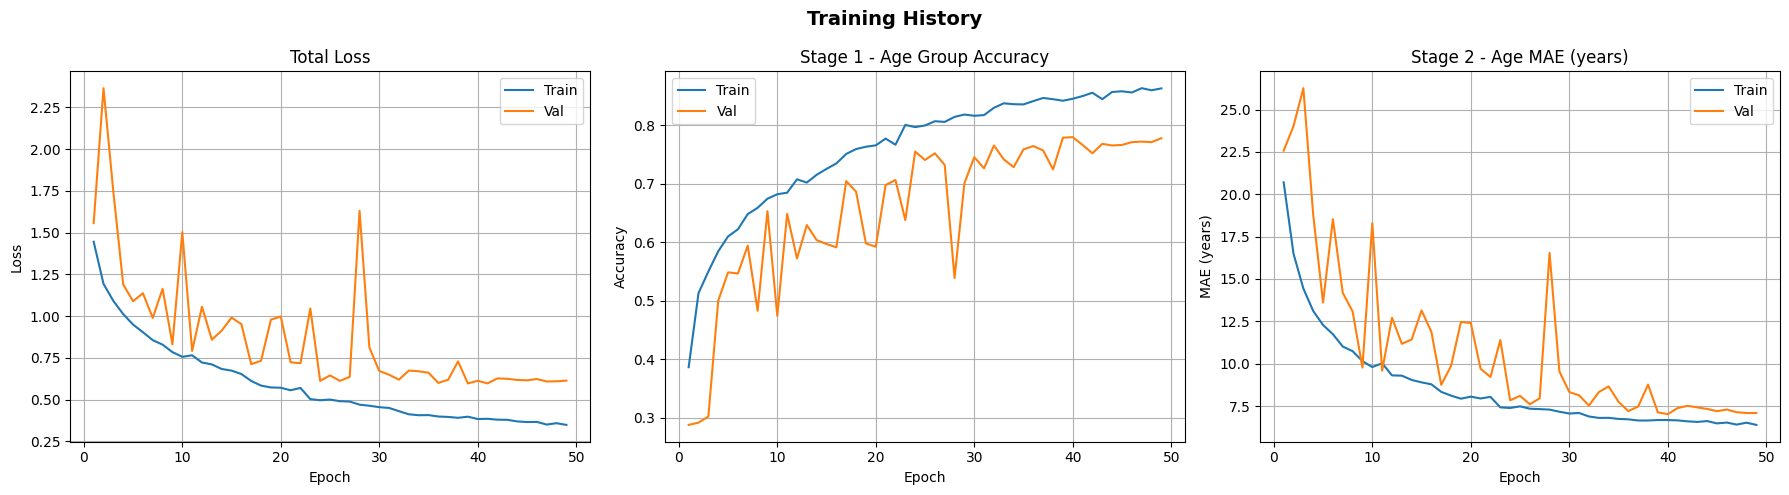

In [11]:
h = history.history
epochs = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs, h['loss'],     label='Train')
axes[0].plot(epochs, h['val_loss'], label='Val')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, h['group_accuracy'],     label='Train')
axes[1].plot(epochs, h['val_group_accuracy'], label='Val')
axes[1].set_title('Stage 1 - Age Group Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

train_mae = np.array(h['age_mae'])     * MAX_AGE
val_mae   = np.array(h['val_age_mae']) * MAX_AGE
axes[2].plot(epochs, train_mae, label='Train')
axes[2].plot(epochs, val_mae,   label='Val')
axes[2].set_title('Stage 2 - Age MAE (years)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE (years)')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

The test set was never seen during training or validation.

In [12]:
true_ages_l, pred_ages_l     = [], []
true_grps_l, pred_grps_l     = [], []

for imgs, labels in test_ds:
    grp_probs, age_norm = model.predict(imgs, verbose=0)
    true_ages_l.extend((labels['age'].numpy() * MAX_AGE).tolist())
    pred_ages_l.extend((age_norm.flatten()    * MAX_AGE).tolist())
    true_grps_l.extend(labels['group'].numpy().tolist())
    pred_grps_l.extend(np.argmax(grp_probs, axis=1).tolist())

true_ages   = np.array(true_ages_l)
pred_ages   = np.array(pred_ages_l)
true_groups = np.array(true_grps_l)
pred_groups = np.array(pred_grps_l)

mae          = np.mean(np.abs(true_ages - pred_ages))
rmse         = np.sqrt(np.mean((true_ages - pred_ages)**2))
group_acc    = np.mean(true_groups == pred_groups)
within_5     = np.mean(np.abs(true_ages - pred_ages) <= 5)  * 100
within_10    = np.mean(np.abs(true_ages - pred_ages) <= 10) * 100

print('=' * 45)
print('         TEST SET RESULTS')
print('=' * 45)
print(f'  Age MAE            : {mae:.2f} years')
print(f'  Age RMSE           : {rmse:.2f} years')
print(f'  Age Group Accuracy : {group_acc*100:.1f}%')
print(f'  Within 5 years     : {within_5:.1f}%')
print(f'  Within 10 years    : {within_10:.1f}%')
print('=' * 45)

         TEST SET RESULTS
  Age MAE            : 7.21 years
  Age RMSE           : 9.77 years
  Age Group Accuracy : 77.7%
  Within 5 years     : 45.4%
  Within 10 years    : 74.4%


## 9. Visualizations for Discussion

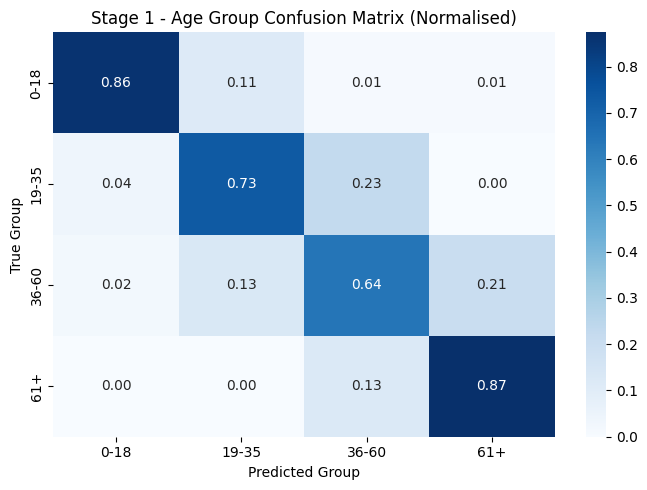

              precision    recall  f1-score   support

        0-18       0.93      0.86      0.90       175
       19-35       0.75      0.73      0.74       175
       36-60       0.64      0.64      0.64       175
         61+       0.80      0.87      0.84       175

    accuracy                           0.78       700
   macro avg       0.78      0.78      0.78       700
weighted avg       0.78      0.78      0.78       700



In [13]:
# Plot 1: Confusion Matrix
cm      = confusion_matrix(true_groups, pred_groups)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=GROUP_LABELS, yticklabels=GROUP_LABELS)
plt.title('Stage 1 - Age Group Confusion Matrix (Normalised)')
plt.ylabel('True Group')
plt.xlabel('Predicted Group')
plt.tight_layout()
plt.show()

print(classification_report(true_groups, pred_groups, target_names=GROUP_LABELS))

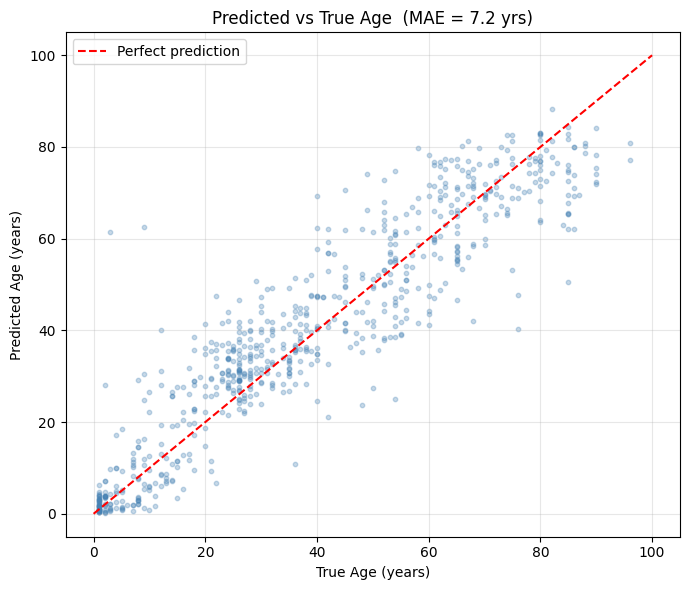

In [14]:
# Plot 2: Predicted vs True Age Scatter
plt.figure(figsize=(7, 6))
plt.scatter(true_ages, pred_ages, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('True Age (years)')
plt.ylabel('Predicted Age (years)')
plt.title(f'Predicted vs True Age  (MAE = {mae:.1f} yrs)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

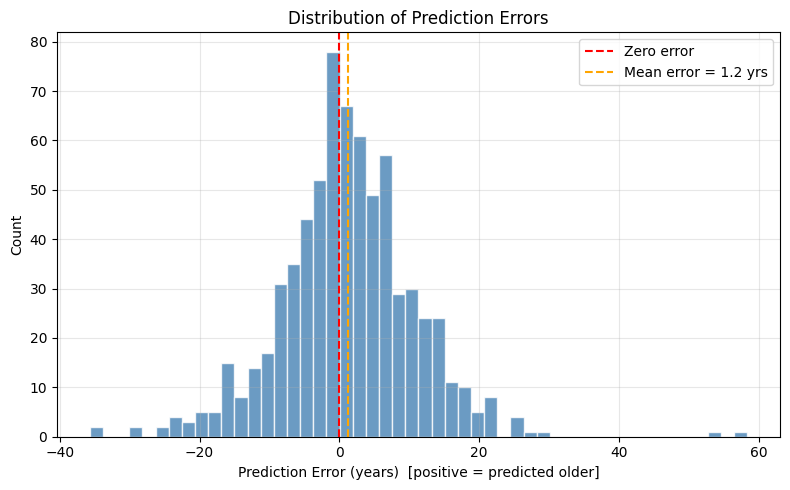

Mean error (bias): 1.19 yrs
Std of error     : 9.70 yrs


In [15]:
# Plot 3: Error Distribution
errors = pred_ages - true_ages

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0,             color='red',    linestyle='--', lw=1.5, label='Zero error')
plt.axvline(errors.mean(), color='orange', linestyle='--', lw=1.5,
            label=f'Mean error = {errors.mean():.1f} yrs')
plt.xlabel('Prediction Error (years)  [positive = predicted older]')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Mean error (bias): {errors.mean():.2f} yrs')
print(f'Std of error     : {errors.std():.2f} yrs')

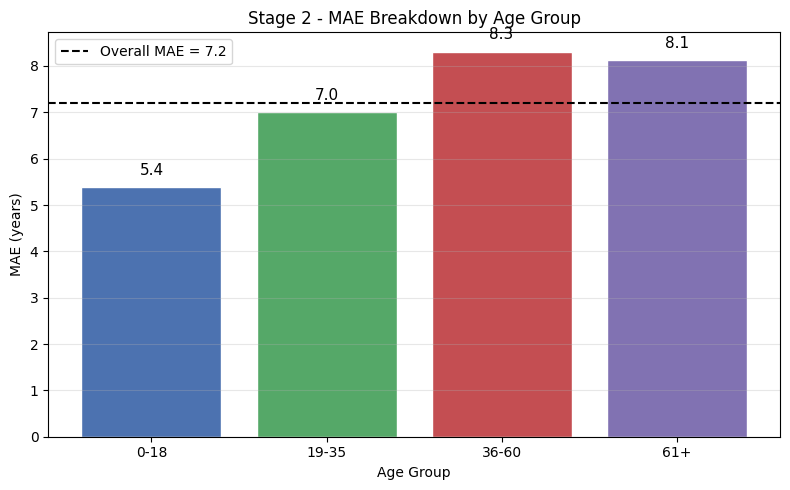

In [16]:
# Plot 4: MAE per Age Group
group_maes = []
for g in range(4):
    mask = true_groups == g
    group_maes.append(np.mean(np.abs(true_ages[mask] - pred_ages[mask])) if mask.sum() > 0 else 0)

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
plt.figure(figsize=(8, 5))
bars = plt.bar(GROUP_LABELS, group_maes, color=colors, edgecolor='white')
plt.axhline(mae, color='black', linestyle='--', lw=1.5, label=f'Overall MAE = {mae:.1f}')
for bar, val in zip(bars, group_maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=11)
plt.xlabel('Age Group'); plt.ylabel('MAE (years)')
plt.title('Stage 2 - MAE Breakdown by Age Group')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

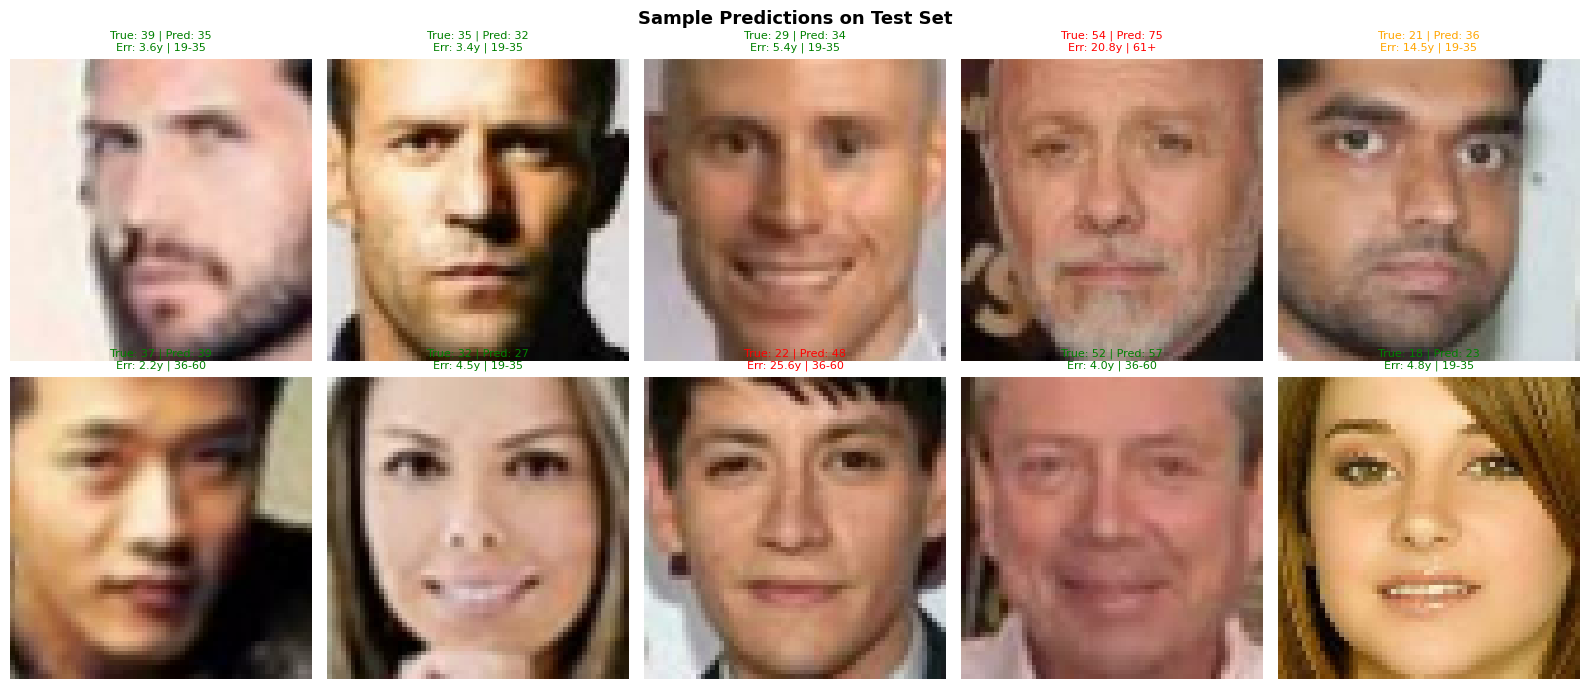

Green = error <= 7 yrs  |  Orange = 7-15 yrs  |  Red = >15 yrs


In [17]:
# Plot 5: Sample Predictions
sample_imgs, sample_true_ages, sample_true_groups = [], [], []
for imgs, labels in test_ds:
    for i in range(len(imgs)):
        sample_imgs.append(imgs[i].numpy())
        sample_true_ages.append(labels['age'].numpy()[i] * MAX_AGE)
        sample_true_groups.append(labels['group'].numpy()[i])
    if len(sample_imgs) >= 100:
        break

idxs = random.sample(range(len(sample_imgs)), 10)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Predictions on Test Set', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, idxs):
    img_batch = np.expand_dims(sample_imgs[idx], 0)
    grp_probs, age_norm = model.predict(img_batch, verbose=0)
    pred_age = float(age_norm[0, 0]) * MAX_AGE
    pred_grp = int(np.argmax(grp_probs[0]))
    true_age = sample_true_ages[idx]
    error    = abs(pred_age - true_age)
    color    = 'green' if error <= 7 else ('orange' if error <= 15 else 'red')
    ax.imshow(sample_imgs[idx]); ax.axis('off')
    ax.set_title(
        f'True: {int(true_age)} | Pred: {pred_age:.0f}\nErr: {error:.1f}y | {GROUP_LABELS[pred_grp]}',
        color=color, fontsize=8
    )

plt.tight_layout(); plt.show()
print('Green = error <= 7 yrs  |  Orange = 7-15 yrs  |  Red = >15 yrs')

## 10. Save & Download Model

In [18]:
model.save('age_detection_ssrnet.keras')
print('Model saved.')

from google.colab import files
files.download('age_detection_ssrnet.keras')

Model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Live Webcam Prediction (Optional)

<IPython.core.display.Javascript object>

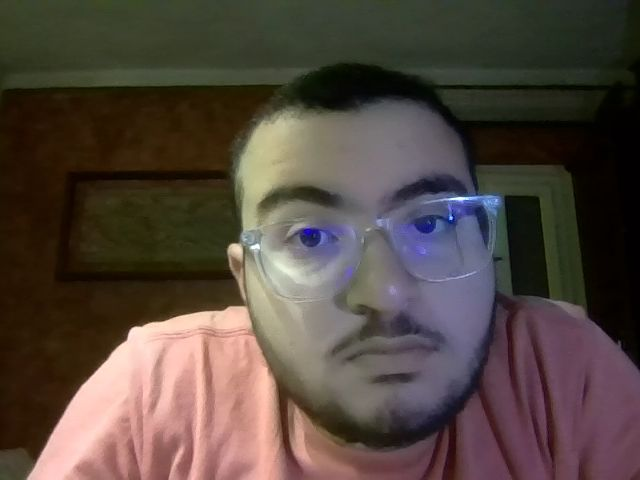

Predicted Age  : 20.6 years
Predicted Group: 19-35 (Young Adult)
Group probs    : {'0-18': '0.41', '19-35': '0.52', '36-60': '0.06', '61+': '0.01'}


In [37]:
from IPython.display import display, Javascript, Image as IPyImage
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Photo';
            div.appendChild(capture);
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def predict_from_file(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) / 255.0
    img = tf.expand_dims(img, 0)
    grp_probs, age_norm = model.predict(img, verbose=0)
    pred_age = float(age_norm[0, 0]) * MAX_AGE
    pred_grp = int(np.argmax(grp_probs[0]))
    print(f'Predicted Age  : {pred_age:.1f} years')
    print(f'Predicted Group: {AGE_GROUPS[pred_grp]}')
    print(f'Group probs    : { {GROUP_LABELS[i]: f"{p:.2f}" for i, p in enumerate(grp_probs[0])} }')

try:
    fname = take_photo()
    display(IPyImage(filename=fname))
    predict_from_file(fname)
except Exception as e:
    print(f'Webcam error: {e}')
    print('You can also run: predict_from_file("path/to/image.jpg")')